In [3]:
# IMPORT LIBRARIES AND LOAD DATA

# Core Libraries
import pandas as pd
import numpy as np
import warnings
warnings.filterwarnings('ignore')
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split, cross_val_score, GridSearchCV
from sklearn.preprocessing import StandardScaler, RobustScaler
from sklearn.impute import SimpleImputer
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from xgboost import XGBClassifier
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.linear_model import Ridge, Lasso
from xgboost import XGBRegressor
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    confusion_matrix, classification_report, roc_auc_score, roc_curve,
    mean_squared_error, mean_absolute_error, r2_score
)
import joblib

# Set display options
pd.set_option('display.max_columns', None)
pd.set_option('display.width', None)

print("✅ All libraries imported successfully!")

✅ All libraries imported successfully!


In [4]:
# LOAD AND EXPLORE THE DATASET

columns = ['Machine_ID', 'Temperature_C', 'Vibration_mm_s', 'Pressure_bar',
           'Acoustic_dB', 'Tool_Wear_mm', 'Operating_Hours', 'Load_pct',
           'Failure_Within_30_Days', 'RUL_Hours']

df = pd.read_excel('/content/drive/MyDrive/predictive_maintenance_dataset.xlsx')


print("PREDICTIVE MAINTENANCE - DATA EXPLORATION")

# Basic Information
print("\n📌 Dataset Shape:", df.shape)
print(f"\n📌 Total Records: {len(df)}")
print(f"📌 Total Features: {len(df.columns)}")

# Display first few rows
print("\n📌 First 5 Records:")
print(df.head())

# Data Types
print("\n📌 Data Types:")
print(df.dtypes)

# Statistical Summary
print("\n📌 Statistical Summary:")
print(df.describe().round(2))

# Target Distribution
print("\n📌 Target Variable Distribution (Failure_Within_30_Days):")
print(df['Failure_Within_30_Days'].value_counts())
print(f"\nFailure Rate: {df['Failure_Within_30_Days'].mean()*100:.2f}%")

PREDICTIVE MAINTENANCE - DATA EXPLORATION

📌 Dataset Shape: (1000, 10)

📌 Total Records: 1000
📌 Total Features: 10

📌 First 5 Records:
   Machine_ID  Temperature_C  Vibration_mm_s  Pressure_bar  Acoustic_dB  \
0          48          79.46            2.12          3.53         58.6   
1           5          60.57            2.54          5.48         64.0   
2          26          73.37            3.06          5.09         64.9   
3           4          62.07            2.16          4.58         60.1   
4          20          78.57            1.35          5.93         63.4   

   Tool_Wear_mm  Operating_Hours  Load_pct  Failure_Within_30_Days  RUL_Hours  
0         1.157             2690      76.1                       0       2182  
1         1.388              614      69.6                       1         73  
2         0.349             3115      92.0                       0        944  
3         0.536             4188      68.1                       0        476  
4         0.11

In [5]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [8]:
import pandas as pd
import numpy as np

df = pd.read_excel('/content/drive/MyDrive/predictive_maintenance_dataset.xlsx')

# Define column names
columns = ['Machine_ID', 'Temperature_C', 'Vibration_mm_s', 'Pressure_bar',
           'Acoustic_dB', 'Tool_Wear_mm', 'Operating_Hours', 'Load_pct',
           'Failure_Within_30_Days', 'RUL_Hours']

print("PREDICTIVE MAINTENANCE - DATA EXPLORATION")

# Basic Information
print("\n📌 Dataset Shape:", df.shape)
print(f"\n📌 Total Records: {len(df)}")
print(f"📌 Total Features: {len(df.columns)}")

# Display first few rows
print("\n📌 First 5 Records:")
print(df.head())

# Data Types
print("\n📌 Data Types:")
print(df.dtypes)

# Statistical Summary
print("\n📌 Statistical Summary:")
print(df.describe().round(2))

# Target Distribution
print("\n📌 Target Variable Distribution (Failure_Within_30_Days):")
print(df['Failure_Within_30_Days'].value_counts())
print(f"\nFailure Rate: {df['Failure_Within_30_Days'].mean()*100:.2f}%")

PREDICTIVE MAINTENANCE - DATA EXPLORATION

📌 Dataset Shape: (1000, 10)

📌 Total Records: 1000
📌 Total Features: 10

📌 First 5 Records:
   Machine_ID  Temperature_C  Vibration_mm_s  Pressure_bar  Acoustic_dB  \
0          48          79.46            2.12          3.53         58.6   
1           5          60.57            2.54          5.48         64.0   
2          26          73.37            3.06          5.09         64.9   
3           4          62.07            2.16          4.58         60.1   
4          20          78.57            1.35          5.93         63.4   

   Tool_Wear_mm  Operating_Hours  Load_pct  Failure_Within_30_Days  RUL_Hours  
0         1.157             2690      76.1                       0       2182  
1         1.388              614      69.6                       1         73  
2         0.349             3115      92.0                       0        944  
3         0.536             4188      68.1                       0        476  
4         0.11

In [9]:
# DATA CLEANING AND PREPROCESSING

print("DATA CLEANING & PREPROCESSING")

print("\n📌 Missing Values Check:")
missing = df.isnull().sum()
print(missing[missing > 0] if missing.sum() > 0 else "No missing values found! ✅")

def handle_missing_values(df):
    df_clean = df.copy()

    numerical_cols = df_clean.select_dtypes(include=[np.number]).columns

    for col in numerical_cols:
        if df_clean[col].isnull().sum() > 0:
            median_val = df_clean[col].median()
            df_clean[col].fillna(median_val, inplace=True)
            print(f"  - Filled {col} with median: {median_val:.2f}")

    return df_clean

df = handle_missing_values(df)

duplicates = df.duplicated().sum()
print(f"\n📌 Duplicate Records: {duplicates}")
if duplicates > 0:
    df = df.drop_duplicates()
    print(f"  - Removed {duplicates} duplicate records")

print("\n📌 Outlier Analysis:")

def detect_outliers_iqr(df, columns):
    outlier_info = {}

    for col in columns:
        Q1 = df[col].quantile(0.25)
        Q3 = df[col].quantile(0.75)
        IQR = Q3 - Q1

        lower_bound = Q1 - 1.5 * IQR
        upper_bound = Q3 + 1.5 * IQR

        outliers = df[(df[col] < lower_bound) | (df[col] > upper_bound)]
        outlier_info[col] = len(outliers)

        if len(outliers) > 0:
            print(f"  - {col}: {len(outliers)} outliers detected")

    return outlier_info

sensor_columns = ['Temperature_C', 'Vibration_mm_s', 'Pressure_bar',
                  'Acoustic_dB', 'Tool_Wear_mm', 'Operating_Hours', 'Load_pct']
outlier_info = detect_outliers_iqr(df, sensor_columns)

def cap_outliers(df, columns, factor=1.5):
    df_capped = df.copy()

    for col in columns:
        Q1 = df_capped[col].quantile(0.25)
        Q3 = df_capped[col].quantile(0.75)
        IQR = Q3 - Q1

        lower_bound = Q1 - factor * IQR
        upper_bound = Q3 + factor * IQR

        df_capped[col] = df_capped[col].clip(lower=lower_bound, upper=upper_bound)

    return df_capped

df = cap_outliers(df, sensor_columns)
print("\n✅ Outliers capped successfully!")

print("\n📌 Data Validation:")
print(f"  - Temperature range: {df['Temperature_C'].min():.1f}°C to {df['Temperature_C'].max():.1f}°C")
print(f"  - Vibration range: {df['Vibration_mm_s'].min():.2f} to {df['Vibration_mm_s'].max():.2f} mm/s")
print(f"  - Operating Hours: {df['Operating_Hours'].min()} to {df['Operating_Hours'].max()} hrs")
print(f"  - RUL range: {df['RUL_Hours'].min()} to {df['RUL_Hours'].max()} hours")

DATA CLEANING & PREPROCESSING

📌 Missing Values Check:
No missing values found! ✅

📌 Duplicate Records: 0

📌 Outlier Analysis:
  - Temperature_C: 4 outliers detected
  - Vibration_mm_s: 9 outliers detected
  - Pressure_bar: 13 outliers detected
  - Acoustic_dB: 15 outliers detected

✅ Outliers capped successfully!

📌 Data Validation:
  - Temperature range: 48.0°C to 92.4°C
  - Vibration range: 0.56 to 3.81 mm/s
  - Operating Hours: 100 to 4991 hrs
  - RUL range: 11 to 2993 hours


EXPLORATORY DATA ANALYSIS


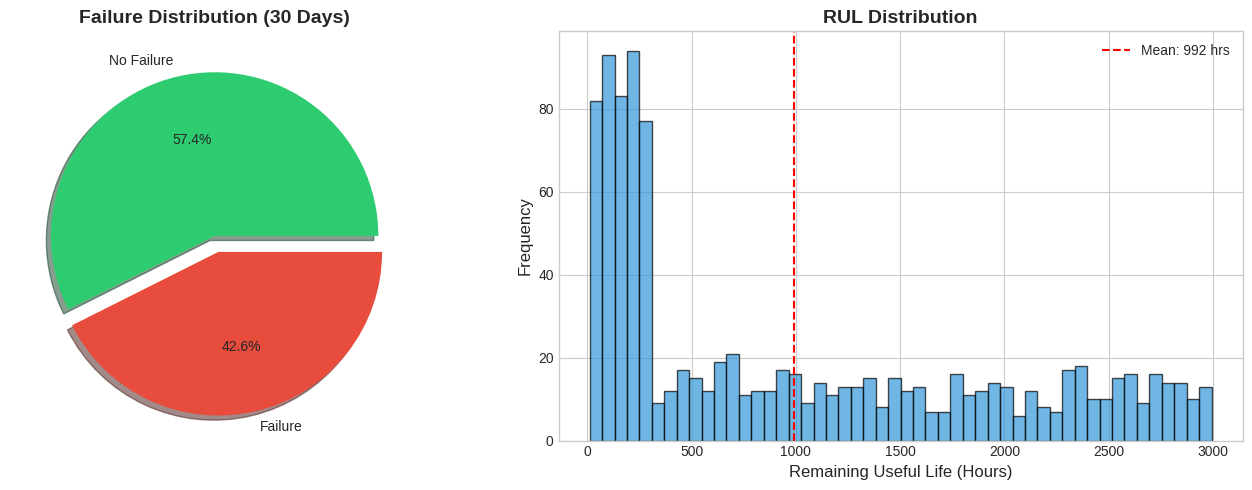

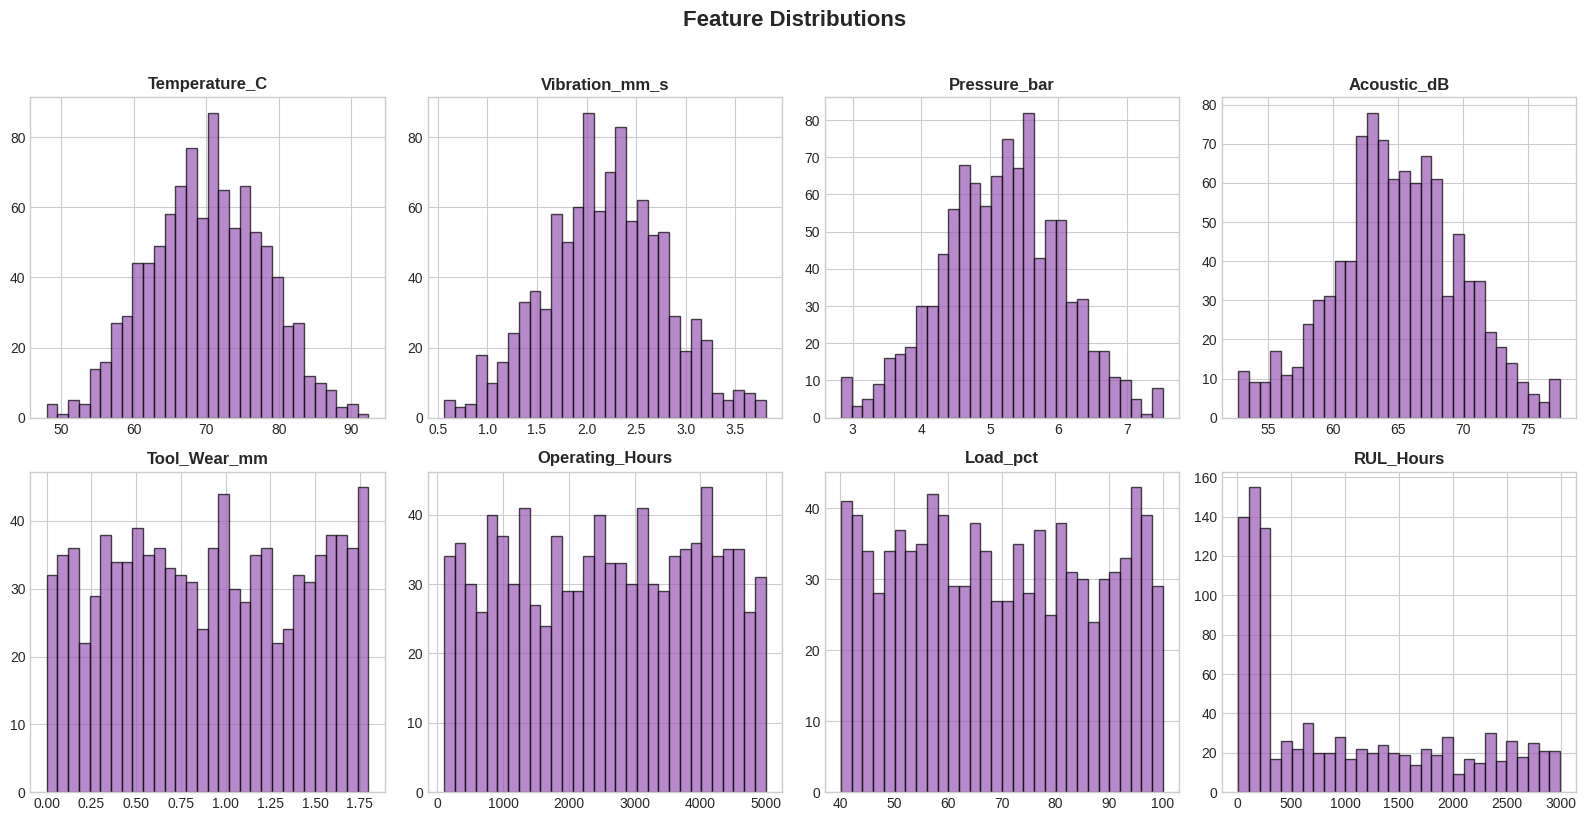


📌 Correlation Analysis:


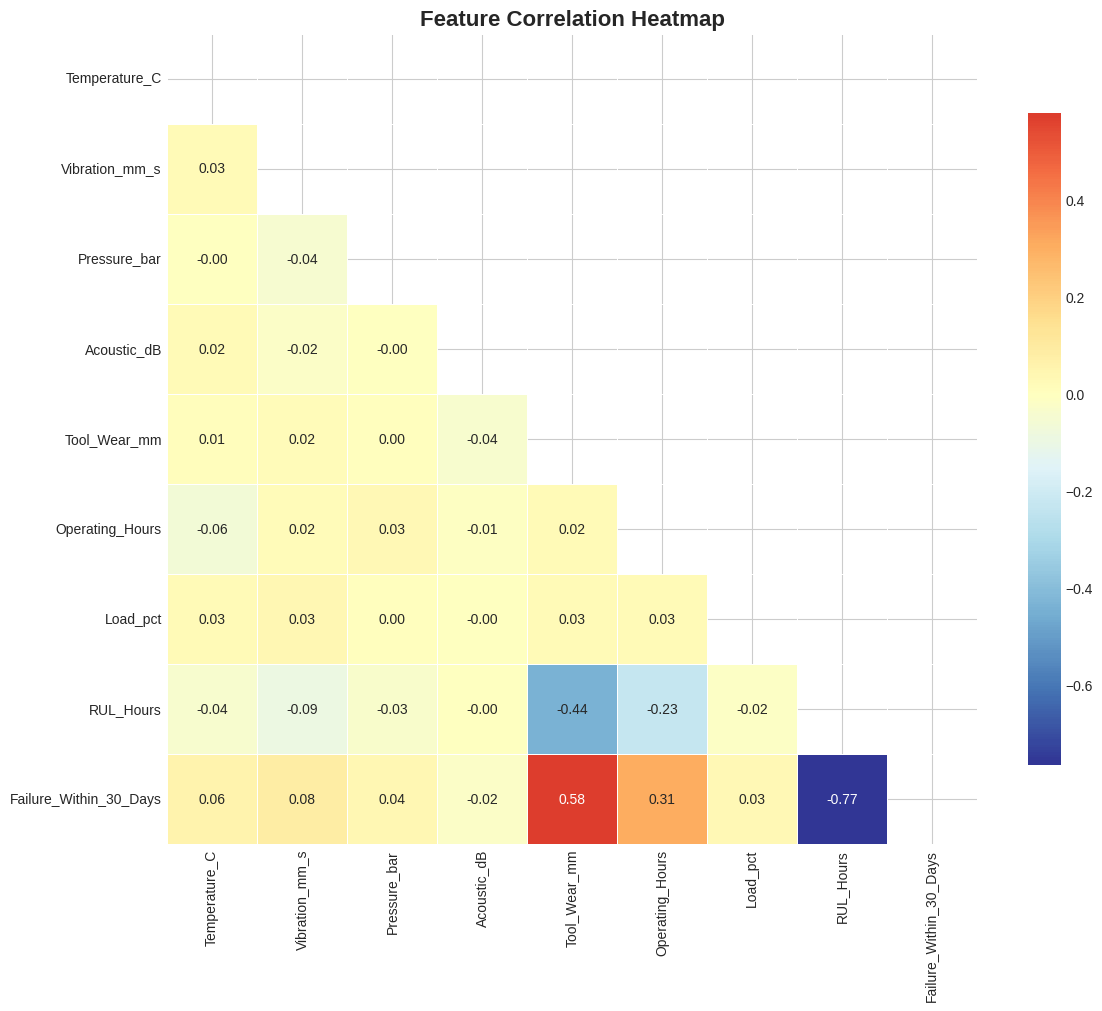


📌 Correlations with Failure_Within_30_Days:
  ↑ Tool_Wear_mm: 0.580
  ↑ Operating_Hours: 0.308
  ↑ Vibration_mm_s: 0.082
  ↑ Temperature_C: 0.056
  ↑ Pressure_bar: 0.039
  ↑ Load_pct: 0.030
  ↓ Acoustic_dB: -0.023
  ↓ RUL_Hours: -0.765


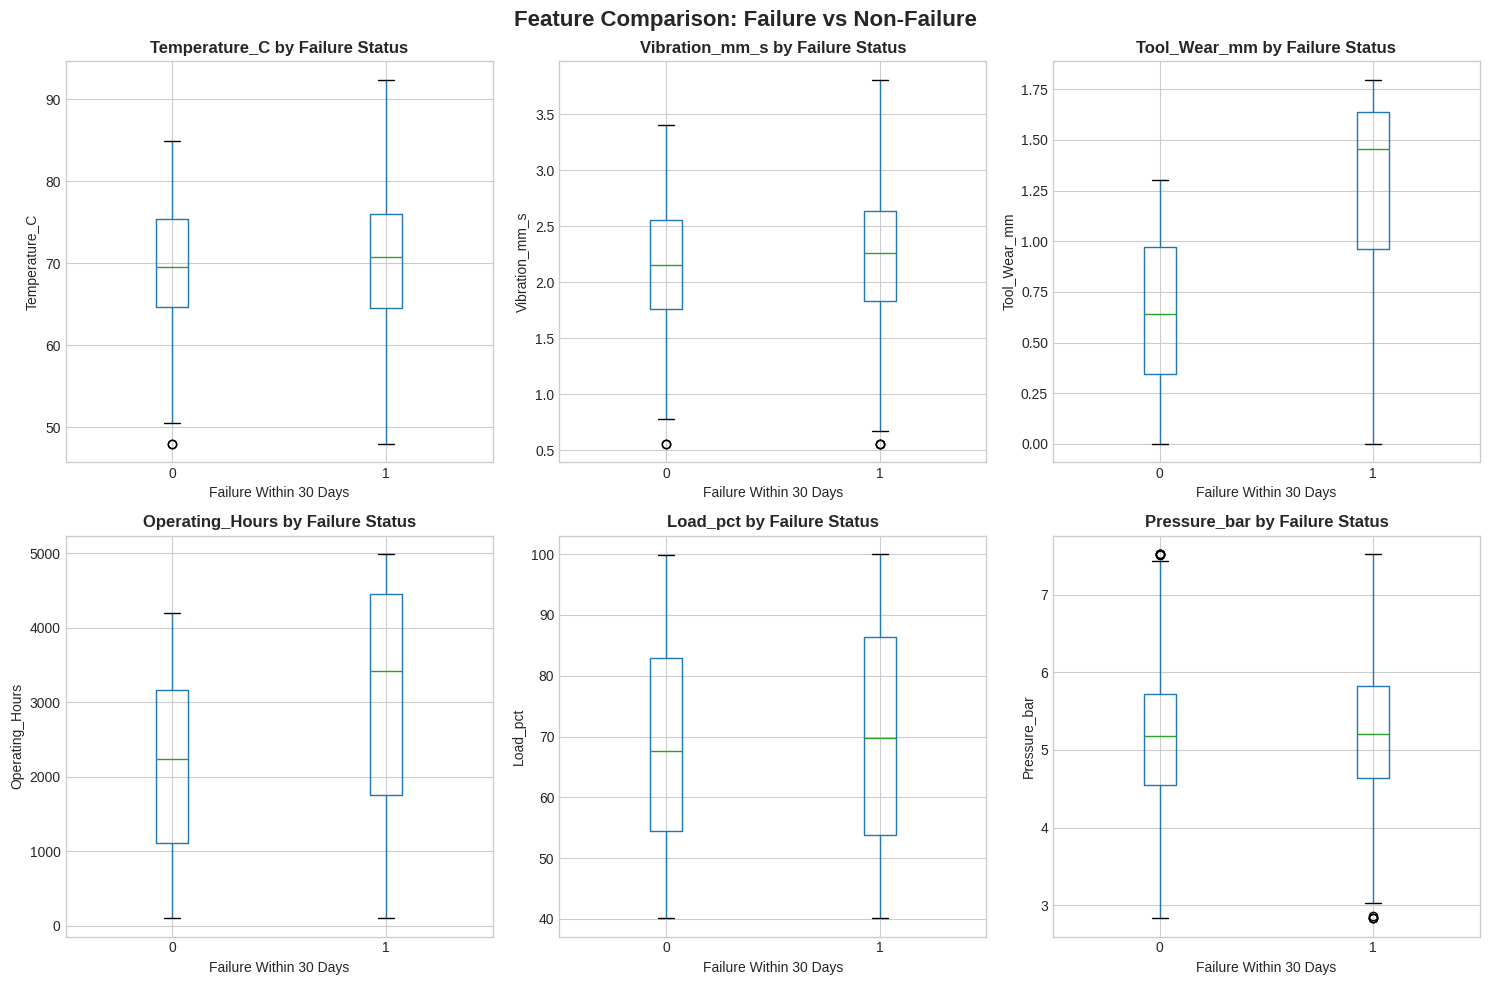


📌 RUL Statistics by Failure Status:
                           mean  median     std  min   max
Failure_Within_30_Days                                    
0                       1612.28  1570.5  796.65  300  2993
1                        156.33   157.5   82.25   11   299


In [10]:
import matplotlib.pyplot as plt
import seaborn as sns

# EXPLORATORY DATA ANALYSIS (EDA)

print("EXPLORATORY DATA ANALYSIS")

# Set style
plt.style.use('seaborn-v0_8-whitegrid')
fig_size = (14, 10)

# 4.1 Target Variable Distribution
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Failure Distribution
failure_counts = df['Failure_Within_30_Days'].value_counts()
colors = ['#2ecc71', '#e74c3c']
axes[0].pie(failure_counts, labels=['No Failure', 'Failure'], autopct='%1.1f%%',
            colors=colors, explode=(0, 0.1), shadow=True)
axes[0].set_title('Failure Distribution (30 Days)', fontsize=14, fontweight='bold')

# RUL Distribution
axes[1].hist(df['RUL_Hours'], bins=50, color='#3498db', edgecolor='black', alpha=0.7)
axes[1].set_xlabel('Remaining Useful Life (Hours)', fontsize=12)
axes[1].set_ylabel('Frequency', fontsize=12)
axes[1].set_title('RUL Distribution', fontsize=14, fontweight='bold')
axes[1].axvline(df['RUL_Hours'].mean(), color='red', linestyle='--',
                label=f'Mean: {df["RUL_Hours"].mean():.0f} hrs')
axes[1].legend()

plt.tight_layout()
plt.savefig('target_distribution.png', dpi=300, bbox_inches='tight')
plt.show()

# 4.2 Feature Distributions
fig, axes = plt.subplots(2, 4, figsize=(16, 8))
axes = axes.flatten()

feature_cols = ['Temperature_C', 'Vibration_mm_s', 'Pressure_bar', 'Acoustic_dB',
                'Tool_Wear_mm', 'Operating_Hours', 'Load_pct', 'RUL_Hours']

for idx, col in enumerate(feature_cols):
    axes[idx].hist(df[col], bins=30, color='#9b59b6', edgecolor='black', alpha=0.7)
    axes[idx].set_title(col, fontsize=12, fontweight='bold')
    axes[idx].set_xlabel('')

plt.suptitle('Feature Distributions', fontsize=16, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('feature_distributions.png', dpi=300, bbox_inches='tight')
plt.show()

print("\n📌 Correlation Analysis:")

correlation_matrix = df[feature_cols + ['Failure_Within_30_Days']].corr()

plt.figure(figsize=(12, 10))
mask = np.triu(np.ones_like(correlation_matrix, dtype=bool))
sns.heatmap(correlation_matrix, mask=mask, annot=True, fmt='.2f',
            cmap='RdYlBu_r', center=0, square=True, linewidths=0.5,
            cbar_kws={'shrink': 0.8})
plt.title('Feature Correlation Heatmap', fontsize=16, fontweight='bold')
plt.tight_layout()
plt.savefig('correlation_heatmap.png', dpi=300, bbox_inches='tight')
plt.show()

print("\n📌 Correlations with Failure_Within_30_Days:")
failure_corr = correlation_matrix['Failure_Within_30_Days'].drop('Failure_Within_30_Days').sort_values(ascending=False)
for feat, corr in failure_corr.items():
    direction = "↑" if corr > 0 else "↓"
    print(f"  {direction} {feat}: {corr:.3f}")

fig, axes = plt.subplots(2, 3, figsize=(15, 10))
axes = axes.flatten()

features_to_plot = ['Temperature_C', 'Vibration_mm_s', 'Tool_Wear_mm',
                    'Operating_Hours', 'Load_pct', 'Pressure_bar']

for idx, feature in enumerate(features_to_plot):
    df.boxplot(column=feature, by='Failure_Within_30_Days', ax=axes[idx])
    axes[idx].set_title(f'{feature} by Failure Status', fontsize=12, fontweight='bold')
    axes[idx].set_xlabel('Failure Within 30 Days')
    axes[idx].set_ylabel(feature)

plt.suptitle('Feature Comparison: Failure vs Non-Failure', fontsize=16, fontweight='bold')
plt.tight_layout()
plt.savefig('feature_by_failure.png', dpi=300, bbox_inches='tight')
plt.show()

print("\n📌 RUL Statistics by Failure Status:")
rul_stats = df.groupby('Failure_Within_30_Days')['RUL_Hours'].agg(['mean', 'median', 'std', 'min', 'max'])
print(rul_stats.round(2))

In [11]:
# FEATURE ENGINEERING

print("FEATURE ENGINEERING")

def engineer_features(df):
    df_eng = df.copy()

    print("\n📌 Creating Interaction Features...")
    df_eng['Temp_Load_Interaction'] = df_eng['Temperature_C'] * df_eng['Load_pct'] / 100
    df_eng['Vibration_Wear_Interaction'] = df_eng['Vibration_mm_s'] * df_eng['Tool_Wear_mm']
    df_eng['Operating_Intensity'] = df_eng['Operating_Hours'] * df_eng['Load_pct'] / 100

    print("📌 Creating Ratio Features...")
    df_eng['Temp_Pressure_Ratio'] = df_eng['Temperature_C'] / (df_eng['Pressure_bar'] + 0.1)
    df_eng['Wear_Rate'] = df_eng['Tool_Wear_mm'] / (df_eng['Operating_Hours'] + 1)

    print("📌 Creating Polynomial Features...")
    df_eng['Temperature_Squared'] = df_eng['Temperature_C'] ** 2
    df_eng['Vibration_Squared'] = df_eng['Vibration_mm_s'] ** 2
    df_eng['Tool_Wear_Squared'] = df_eng['Tool_Wear_mm'] ** 2

    print("📌 Creating Risk Score Features...")
    temp_norm = (df_eng['Temperature_C'] - df_eng['Temperature_C'].min()) / \
                (df_eng['Temperature_C'].max() - df_eng['Temperature_C'].min())
    vib_norm = (df_eng['Vibration_mm_s'] - df_eng['Vibration_mm_s'].min()) / \
               (df_eng['Vibration_mm_s'].max() - df_eng['Vibration_mm_s'].min())
    wear_norm = (df_eng['Tool_Wear_mm'] - df_eng['Tool_Wear_mm'].min()) / \
                (df_eng['Tool_Wear_mm'].max() - df_eng['Tool_Wear_mm'].min())

    df_eng['Risk_Score'] = (temp_norm * 0.3 + vib_norm * 0.3 + wear_norm * 0.4)

    print("📌 Creating Binned Features...")
    df_eng['Temp_Zone'] = pd.cut(df_eng['Temperature_C'],
                                  bins=[0, 60, 70, 80, 100],
                                  labels=[0, 1, 2, 3]).astype(int)
    df_eng['Operating_Category'] = pd.cut(df_eng['Operating_Hours'],
                                           bins=[0, 1000, 2500, 4000, 6000],
                                           labels=[0, 1, 2, 3]).astype(int)

    print("📌 Creating Machine-level Statistics...")
    machine_temp_mean = df_eng.groupby('Machine_ID')['Temperature_C'].transform('mean')
    df_eng['Machine_Temp_Deviation'] = df_eng['Temperature_C'] - machine_temp_mean
    df_eng['Machine_Hours_Rank'] = df_eng.groupby('Machine_ID')['Operating_Hours'].rank(pct=True)

    print(f"\n✅ Total features after engineering: {len(df_eng.columns)}")
    print(f"📌 New features created: {len(df_eng.columns) - len(df.columns)}")

    return df_eng

df_engineered = engineer_features(df)

new_features = [col for col in df_engineered.columns if col not in df.columns]
print("\n📌 New Features Created:")
for feat in new_features:
    print(f"  • {feat}")

FEATURE ENGINEERING

📌 Creating Interaction Features...
📌 Creating Ratio Features...
📌 Creating Polynomial Features...
📌 Creating Risk Score Features...
📌 Creating Binned Features...
📌 Creating Machine-level Statistics...

✅ Total features after engineering: 23
📌 New features created: 13

📌 New Features Created:
  • Temp_Load_Interaction
  • Vibration_Wear_Interaction
  • Operating_Intensity
  • Temp_Pressure_Ratio
  • Wear_Rate
  • Temperature_Squared
  • Vibration_Squared
  • Tool_Wear_Squared
  • Risk_Score
  • Temp_Zone
  • Operating_Category
  • Machine_Temp_Deviation
  • Machine_Hours_Rank


In [12]:
# DATA PREPARATION FOR MODELING
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import RobustScaler
import joblib

print("DATA PREPARATION FOR MODELING")

exclude_cols = ['Machine_ID', 'Failure_Within_30_Days', 'RUL_Hours']
feature_columns = [col for col in df_engineered.columns if col not in exclude_cols]

X = df_engineered[feature_columns]
y_classification = df_engineered['Failure_Within_30_Days']
y_regression = df_engineered['RUL_Hours']

print(f"\n📌 Feature Matrix Shape: {X.shape}")
print(f"📌 Number of Features: {len(feature_columns)}")
print(f"\n📌 Features Used:")
for i, feat in enumerate(feature_columns, 1):
    print(f"  {i:2d}. {feat}")

X_train, X_test, y_train_clf, y_test_clf, y_train_reg, y_test_reg = train_test_split(
    X, y_classification, y_regression,
    test_size=0.2,
    random_state=42,
    stratify=y_classification
)

print(f"\n📌 Training Set Size: {len(X_train)} ({len(X_train)/len(X)*100:.1f}%)的发展")
print(f"📌 Test Set Size: {len(X_test)} ({len(X_test)/len(X)*100:.1f}%)的发展")

print(f"\n📌 Training Set Failure Rate: {y_train_clf.mean()*100:.2f}%")
print(f"📌 Test Set Failure Rate: {y_test_clf.mean()*100:.2f}%")

print("\n📌 Applying Feature Scaling...")

scaler = RobustScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

X_train_scaled = pd.DataFrame(X_train_scaled, columns=feature_columns, index=X_train.index)
X_test_scaled = pd.DataFrame(X_test_scaled, columns=feature_columns, index=X_test.index)

print("✅ Feature scaling completed!")

joblib.dump(scaler, 'scaler.pkl')
print("✅ Scaler saved to 'scaler.pkl'")

print("\n📌 Class Distribution Analysis:")
print(f"  Class 0 (No Failure): {(y_train_clf == 0).sum()} samples")
print(f"  Class 1 (Failure): {(y_train_clf == 1).sum()} samples")
print(f"  Imbalance Ratio: 1:{(y_train_clf == 0).sum() / (y_train_clf == 1).sum():.2f}")

from sklearn.utils.class_weight import compute_class_weight

class_weights = compute_class_weight('balanced',
                                      classes=np.unique(y_train_clf),
                                      y=y_train_clf)
class_weight_dict = dict(zip(np.unique(y_train_clf), class_weights))
print(f"\n📌 Computed Class Weights: {class_weight_dict}")

DATA PREPARATION FOR MODELING

📌 Feature Matrix Shape: (1000, 20)
📌 Number of Features: 20

📌 Features Used:
   1. Temperature_C
   2. Vibration_mm_s
   3. Pressure_bar
   4. Acoustic_dB
   5. Tool_Wear_mm
   6. Operating_Hours
   7. Load_pct
   8. Temp_Load_Interaction
   9. Vibration_Wear_Interaction
  10. Operating_Intensity
  11. Temp_Pressure_Ratio
  12. Wear_Rate
  13. Temperature_Squared
  14. Vibration_Squared
  15. Tool_Wear_Squared
  16. Risk_Score
  17. Temp_Zone
  18. Operating_Category
  19. Machine_Temp_Deviation
  20. Machine_Hours_Rank

📌 Training Set Size: 800 (80.0%)的发展
📌 Test Set Size: 200 (20.0%)的发展

📌 Training Set Failure Rate: 42.62%
📌 Test Set Failure Rate: 42.50%

📌 Applying Feature Scaling...
✅ Feature scaling completed!
✅ Scaler saved to 'scaler.pkl'

📌 Class Distribution Analysis:
  Class 0 (No Failure): 459 samples
  Class 1 (Failure): 341 samples
  Imbalance Ratio: 1:1.35

📌 Computed Class Weights: {np.int64(0): np.float64(0.8714596949891068), np.int64(1): 

CLASSIFICATION MODEL TRAINING

📌 Training Classification Models...

Training Logistic Regression...
  ✓ Accuracy: 0.8550
  ✓ Precision: 0.8256
  ✓ Recall: 0.8353
  ✓ F1-Score: 0.8304
  ✓ ROC-AUC: 0.9419
  ✓ CV F1 (5-fold): 0.8244 ± 0.0239

Training Random Forest...
  ✓ Accuracy: 1.0000
  ✓ Precision: 1.0000
  ✓ Recall: 1.0000
  ✓ F1-Score: 1.0000
  ✓ ROC-AUC: 1.0000
  ✓ CV F1 (5-fold): 0.9806 ± 0.0223

Training Gradient Boosting...
  ✓ Accuracy: 1.0000
  ✓ Precision: 1.0000
  ✓ Recall: 1.0000
  ✓ F1-Score: 1.0000
  ✓ ROC-AUC: 1.0000
  ✓ CV F1 (5-fold): 0.9941 ± 0.0055

Training XGBoost...
  ✓ Accuracy: 1.0000
  ✓ Precision: 1.0000
  ✓ Recall: 1.0000
  ✓ F1-Score: 1.0000
  ✓ ROC-AUC: 1.0000
  ✓ CV F1 (5-fold): 0.9837 ± 0.0152


📌 Classification Model Comparison:
--------------------------------------------------------------------------------
Model                       Accuracy  Precision     Recall   F1-Score    ROC-AUC
------------------------------------------------------------------

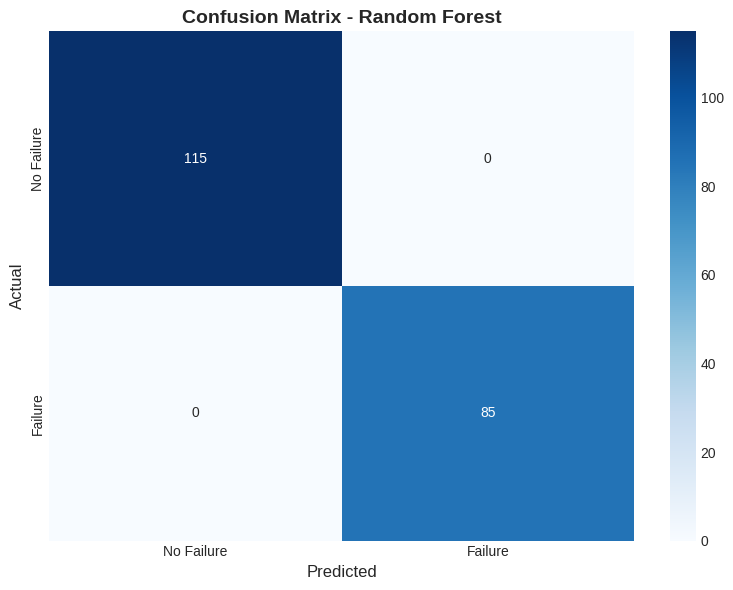

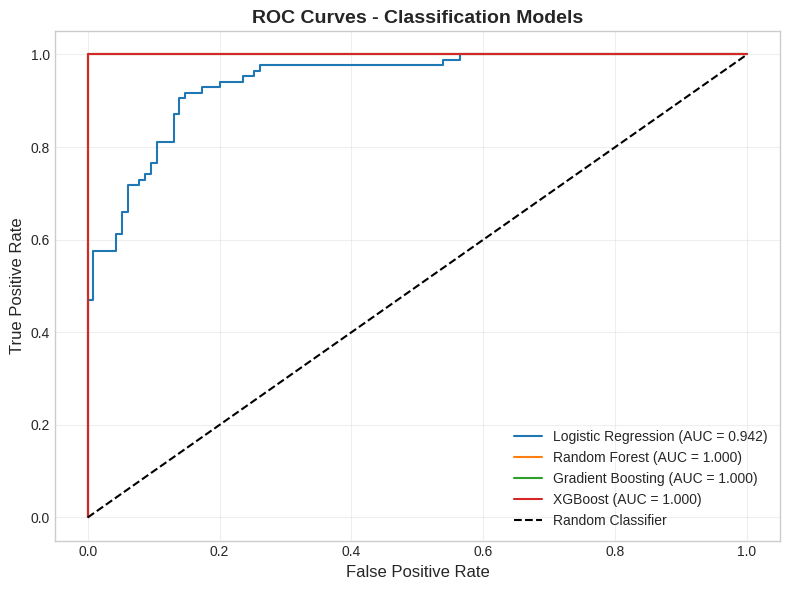

In [13]:
# CLASSIFICATION MODEL TRAINING (Failure_Within_30_Days)
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.preprocessing import StandardScaler, RobustScaler
from sklearn.impute import SimpleImputer
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from xgboost import XGBClassifier
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    confusion_matrix, classification_report, roc_auc_score, roc_curve
)
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

print("CLASSIFICATION MODEL TRAINING")

classification_models = {
    'Logistic Regression': LogisticRegression(
        class_weight='balanced',
        max_iter=1000,
        random_state=42
    ),
    'Random Forest': RandomForestClassifier(
        n_estimators=200,
        max_depth=15,
        min_samples_split=5,
        class_weight='balanced',
        random_state=42,
        n_jobs=-1
    ),
    'Gradient Boosting': GradientBoostingClassifier(
        n_estimators=200,
        max_depth=5,
        learning_rate=0.1,
        random_state=42
    ),
    'XGBoost': XGBClassifier(
        n_estimators=200,
        max_depth=6,
        learning_rate=0.1,
        scale_pos_weight=(y_train_clf == 0).sum() / (y_train_clf == 1).sum(),
        random_state=42,
        use_label_encoder=False,
        eval_metric='logloss'
    )
}

classification_results = {}

print("\n📌 Training Classification Models...\n")

for name, model in classification_models.items():
    print(f"Training {name}...")

    model.fit(X_train_scaled, y_train_clf)

    y_pred = model.predict(X_test_scaled)
    y_pred_proba = model.predict_proba(X_test_scaled)[:, 1] if hasattr(model, 'predict_proba') else None

    accuracy = accuracy_score(y_test_clf, y_pred)
    precision = precision_score(y_test_clf, y_pred)
    recall = recall_score(y_test_clf, y_pred)
    f1 = f1_score(y_test_clf, y_pred)
    roc_auc = roc_auc_score(y_test_clf, y_pred_proba) if y_pred_proba is not None else None

    cv_scores = cross_val_score(model, X_train_scaled, y_train_clf, cv=5, scoring='f1')

    classification_results[name] = {
        'model': model,
        'accuracy': accuracy,
        'precision': precision,
        'recall': recall,
        'f1_score': f1,
        'roc_auc': roc_auc,
        'cv_f1_mean': cv_scores.mean(),
        'cv_f1_std': cv_scores.std(),
        'predictions': y_pred,
        'probabilities': y_pred_proba
    }

    print(f"  ✓ Accuracy: {accuracy:.4f}")
    print(f"  ✓ Precision: {precision:.4f}")
    print(f"  ✓ Recall: {recall:.4f}")
    print(f"  ✓ F1-Score: {f1:.4f}")
    print(f"  ✓ ROC-AUC: {roc_auc:.4f}" if roc_auc else "")
    print(f"  ✓ CV F1 (5-fold): {cv_scores.mean():.4f} ± {cv_scores.std():.4f}")
    print()

print("\n📌 Classification Model Comparison:")
print("-" * 80)
print(f"{'Model':<25} {'Accuracy':>10} {'Precision':>10} {'Recall':>10} {'F1-Score':>10} {'ROC-AUC':>10}")
print("-" * 80)

for name, results in classification_results.items():
    print(f"{name:<25} {results['accuracy']:>10.4f} {results['precision']:>10.4f} "
          f"{results['recall']:>10.4f} {results['f1_score']:>10.4f} "
          f"{results['roc_auc']:>10.4f}" if results['roc_auc'] else "")

best_clf_name = max(classification_results, key=lambda x: classification_results[x]['f1_score'])
best_clf_model = classification_results[best_clf_name]['model']
print(f"\n🏆 Best Classification Model: {best_clf_name}")
print(f"   F1-Score: {classification_results[best_clf_name]['f1_score']:.4f}")

print(f"\n📌 Detailed Evaluation - {best_clf_name}:")
print("\nClassification Report:")
print(classification_report(y_test_clf, classification_results[best_clf_name]['predictions'],
                           target_names=['No Failure', 'Failure']))

plt.figure(figsize=(8, 6))
cm = confusion_matrix(y_test_clf, classification_results[best_clf_name]['predictions'])
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['No Failure', 'Failure'],
            yticklabels=['No Failure', 'Failure'])
plt.xlabel('Predicted', fontsize=12)
plt.ylabel('Actual', fontsize=12)
plt.title(f'Confusion Matrix - {best_clf_name}', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('confusion_matrix.png', dpi=300, bbox_inches='tight')
plt.show()

plt.figure(figsize=(8, 6))
for name, results in classification_results.items():
    if results['probabilities'] is not None:
        fpr, tpr, _ = roc_curve(y_test_clf, results['probabilities'])
        plt.plot(fpr, tpr, label=f"{name} (AUC = {results['roc_auc']:.3f})")

plt.plot([0, 1], [0, 1], 'k--', label='Random Classifier')
plt.xlabel('False Positive Rate', fontsize=12)
plt.ylabel('True Positive Rate', fontsize=12)
plt.title('ROC Curves - Classification Models', fontsize=14, fontweight='bold')
plt.legend(loc='lower right')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('roc_curves.png', dpi=300, bbox_inches='tight')
plt.show()

REGRESSION MODEL TRAINING (RUL Prediction)

📌 Training Regression Models...

Training Ridge Regression...
  ✓ RMSE: 735.17 hours
  ✓ MAE: 604.64 hours
  ✓ R² Score: 0.3015
  ✓ MAPE: 274.16%
  ✓ CV RMSE (5-fold): 788.53 ± 48.43

Training Lasso Regression...
  ✓ RMSE: 736.50 hours
  ✓ MAE: 607.42 hours
  ✓ R² Score: 0.2989
  ✓ MAPE: 275.89%
  ✓ CV RMSE (5-fold): 789.01 ± 45.11

Training Random Forest...
  ✓ RMSE: 612.85 hours
  ✓ MAE: 432.33 hours
  ✓ R² Score: 0.5146
  ✓ MAPE: 81.35%
  ✓ CV RMSE (5-fold): 649.66 ± 65.70

Training Gradient Boosting...
  ✓ RMSE: 672.65 hours
  ✓ MAE: 487.14 hours
  ✓ R² Score: 0.4152
  ✓ MAPE: 94.32%
  ✓ CV RMSE (5-fold): 711.72 ± 66.97

Training XGBoost...
  ✓ RMSE: 690.04 hours
  ✓ MAE: 499.88 hours
  ✓ R² Score: 0.3846
  ✓ MAPE: 103.28%
  ✓ CV RMSE (5-fold): 699.01 ± 46.49


📌 Regression Model Comparison:
------------------------------------------------------------------------------------------
Model                             RMSE          MAE       

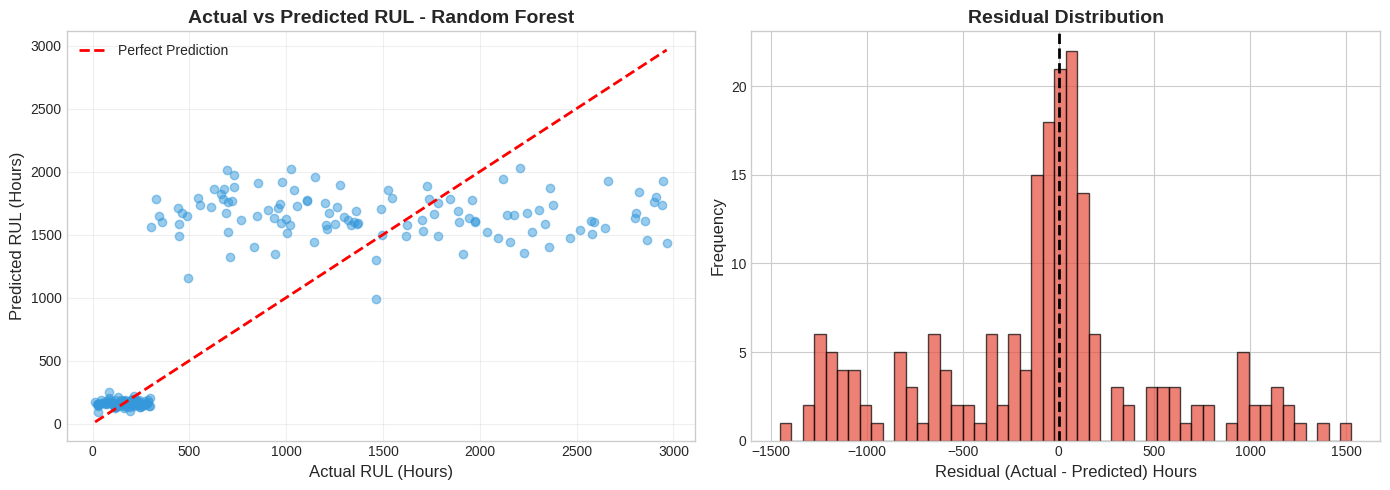


📌 Residual Analysis:
  Mean Residual: -87.96 hours (should be ~0)
  Residual Std: 608.03 hours
  95% Prediction Interval: ±1191.74 hours


In [14]:
# REGRESSION MODEL TRAINING (RUL_Hours)(Remaining Useful Life)
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.preprocessing import StandardScaler, RobustScaler
from sklearn.impute import SimpleImputer
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from xgboost import XGBClassifier
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.linear_model import Ridge, Lasso
from xgboost import XGBRegressor
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    confusion_matrix, classification_report, roc_auc_score, roc_curve,
    mean_squared_error, mean_absolute_error, r2_score
)
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

print("REGRESSION MODEL TRAINING (RUL Prediction)")

regression_models = {
    'Ridge Regression': Ridge(alpha=1.0, random_state=42),
    'Lasso Regression': Lasso(alpha=0.1, random_state=42),
    'Random Forest': RandomForestRegressor(
        n_estimators=200,
        max_depth=15,
        min_samples_split=5,
        random_state=42,
        n_jobs=-1
    ),
    'Gradient Boosting': GradientBoostingRegressor(
        n_estimators=200,
        max_depth=5,
        learning_rate=0.1,
        random_state=42
    ),
    'XGBoost': XGBRegressor(
        n_estimators=200,
        max_depth=6,
        learning_rate=0.1,
        random_state=42
    )
}

regression_results = {}

print("\n📌 Training Regression Models...\n")
for name, model in regression_models.items():
    print(f"Training {name}...")

    model.fit(X_train_scaled, y_train_reg)
    y_pred = model.predict(X_test_scaled)

    mse = mean_squared_error(y_test_reg, y_pred)
    rmse = np.sqrt(mse)
    mae = mean_absolute_error(y_test_reg, y_pred)
    r2 = r2_score(y_test_reg, y_pred)

    mape = np.mean(np.abs((y_test_reg - y_pred) / (y_test_reg + 1))) * 100

    cv_scores = cross_val_score(model, X_train_scaled, y_train_reg,
                                 cv=5, scoring='neg_root_mean_squared_error')
    cv_rmse = -cv_scores.mean()
    cv_rmse_std = cv_scores.std()

    regression_results[name] = {
        'model': model,
        'mse': mse,
        'rmse': rmse,
        'mae': mae,
        'r2': r2,
        'mape': mape,
        'cv_rmse': cv_rmse,
        'cv_rmse_std': cv_rmse_std,
        'predictions': y_pred
    }

    print(f"  ✓ RMSE: {rmse:.2f} hours")
    print(f"  ✓ MAE: {mae:.2f} hours")
    print(f"  ✓ R² Score: {r2:.4f}")
    print(f"  ✓ MAPE: {mape:.2f}%")
    print(f"  ✓ CV RMSE (5-fold): {cv_rmse:.2f} ± {cv_rmse_std:.2f}")
    print()

print("\n📌 Regression Model Comparison:")
print("-" * 90)
print(f"{'Model':<25} {'RMSE':>12} {'MAE':>12} {'R²':>10} {'MAPE (%)':>10} {'CV RMSE':>12}")
print("-" * 90)

for name, results in regression_results.items():
    print(f"{name:<25} {results['rmse']:>12.2f} {results['mae']:>12.2f} "
          f"{results['r2']:>10.4f} {results['mape']:>10.2f} {results['cv_rmse']:>12.2f}")

best_reg_name = min(regression_results, key=lambda x: regression_results[x]['rmse'])
best_reg_model = regression_results[best_reg_name]['model']
print(f"\n🏆 Best Regression Model: {best_reg_name}")
print(f"   RMSE: {regression_results[best_reg_name]['rmse']:.2f} hours")
print(f"   R² Score: {regression_results[best_reg_name]['r2']:.4f}")

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
best_predictions = regression_results[best_reg_name]['predictions']
axes[0].scatter(y_test_reg, best_predictions, alpha=0.5, color='#3498db')
axes[0].plot([y_test_reg.min(), y_test_reg.max()],
             [y_test_reg.min(), y_test_reg.max()],
             'r--', lw=2, label='Perfect Prediction')
axes[0].set_xlabel('Actual RUL (Hours)', fontsize=12)
axes[0].set_ylabel('Predicted RUL (Hours)', fontsize=12)
axes[0].set_title(f'Actual vs Predicted RUL - {best_reg_name}', fontsize=14, fontweight='bold')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

residuals = y_test_reg - best_predictions
axes[1].hist(residuals, bins=50, color='#e74c3c', edgecolor='black', alpha=0.7)
axes[1].axvline(0, color='black', linestyle='--', lw=2)
axes[1].set_xlabel('Residual (Actual - Predicted) Hours', fontsize=12)
axes[1].set_ylabel('Frequency', fontsize=12)
axes[1].set_title('Residual Distribution', fontsize=14, fontweight='bold')

plt.tight_layout()
plt.savefig('regression_results.png', dpi=300, bbox_inches='tight')
plt.show()
print("\n📌 Residual Analysis:")
print(f"  Mean Residual: {residuals.mean():.2f} hours (should be ~0)")
print(f"  Residual Std: {residuals.std():.2f} hours")
print(f"  95% Prediction Interval: ±{1.96 * residuals.std():.2f} hours")

In [15]:
# HYPERPARAMETER TUNING
from sklearn.model_selection import GridSearchCV

print("HYPERPARAMETER TUNING")
print("\n📌 Tuning Classification Model...")

clf_param_grid = {
    'n_estimators': [100, 200, 300],
    'max_depth': [4, 6, 8],
    'learning_rate': [0.05, 0.1, 0.15],
    'min_child_weight': [1, 3, 5],
    'subsample': [0.8, 0.9, 1.0]
}

xgb_clf = XGBClassifier(
    scale_pos_weight=(y_train_clf == 0).sum() / (y_train_clf == 1).sum(),
    random_state=42,
    use_label_encoder=False,
    eval_metric='logloss'
)

clf_param_grid_reduced = {
    'n_estimators': [150, 200],
    'max_depth': [5, 6, 7],
    'learning_rate': [0.08, 0.1, 0.12]
}

clf_grid_search = GridSearchCV(
    xgb_clf,
    clf_param_grid_reduced,
    cv=5,
    scoring='f1',
    n_jobs=-1,
    verbose=1
)

clf_grid_search.fit(X_train_scaled, y_train_clf)

print(f"\n✅ Best Classification Parameters:")
for param, value in clf_grid_search.best_params_.items():
    print(f"   {param}: {value}")
print(f"\n📌 Best CV F1-Score: {clf_grid_search.best_score_:.4f}")

best_clf_tuned = clf_grid_search.best_estimator_

print("\n📌 Tuning Regression Model...")

reg_param_grid_reduced = {
    'n_estimators': [150, 200],
    'max_depth': [5, 6, 7],
    'learning_rate': [0.08, 0.1, 0.12]
}

xgb_reg = XGBRegressor(random_state=42)

reg_grid_search = GridSearchCV(
    xgb_reg,
    reg_param_grid_reduced,
    cv=5,
    scoring='neg_root_mean_squared_error',
    n_jobs=-1,
    verbose=1
)

reg_grid_search.fit(X_train_scaled, y_train_reg)

print(f"\n✅ Best Regression Parameters:")
for param, value in reg_grid_search.best_params_.items():
    print(f"   {param}: {value}")
print(f"\n📌 Best CV RMSE: {-reg_grid_search.best_score_:.2f} hours")

best_reg_tuned = reg_grid_search.best_estimator_

print("FINAL MODEL EVALUATION (After Tuning)")


y_pred_clf_final = best_clf_tuned.predict(X_test_scaled)
y_prob_clf_final = best_clf_tuned.predict_proba(X_test_scaled)[:, 1]

print("\n📌 Tuned Classification Model Performance:")
print(f"  Accuracy: {accuracy_score(y_test_clf, y_pred_clf_final):.4f}")
print(f"  Precision: {precision_score(y_test_clf, y_pred_clf_final):.4f}")
print(f"  Recall: {recall_score(y_test_clf, y_pred_clf_final):.4f}")
print(f"  F1-Score: {f1_score(y_test_clf, y_pred_clf_final):.4f}")
print(f"  ROC-AUC: {roc_auc_score(y_test_clf, y_prob_clf_final):.4f}")

y_pred_reg_final = best_reg_tuned.predict(X_test_scaled)

print("\n📌 Tuned Regression Model Performance:")
print(f"  RMSE: {np.sqrt(mean_squared_error(y_test_reg, y_pred_reg_final)):.2f} hours")
print(f"  MAE: {mean_absolute_error(y_test_reg, y_pred_reg_final):.2f} hours")
print(f"  R² Score: {r2_score(y_test_reg, y_pred_reg_final):.4f}")

HYPERPARAMETER TUNING

📌 Tuning Classification Model...
Fitting 5 folds for each of 18 candidates, totalling 90 fits

✅ Best Classification Parameters:
   learning_rate: 0.08
   max_depth: 5
   n_estimators: 150

📌 Best CV F1-Score: 0.9837

📌 Tuning Regression Model...
Fitting 5 folds for each of 18 candidates, totalling 90 fits

✅ Best Regression Parameters:
   learning_rate: 0.1
   max_depth: 7
   n_estimators: 150

📌 Best CV RMSE: 693.93 hours
FINAL MODEL EVALUATION (After Tuning)

📌 Tuned Classification Model Performance:
  Accuracy: 1.0000
  Precision: 1.0000
  Recall: 1.0000
  F1-Score: 1.0000
  ROC-AUC: 1.0000

📌 Tuned Regression Model Performance:
  RMSE: 680.78 hours
  MAE: 482.61 hours
  R² Score: 0.4010


FEATURE IMPORTANCE ANALYSIS

📌 Top 15 Features for Failure Prediction:
                   Feature  Importance
              Tool_Wear_mm    0.424916
           Operating_Hours    0.327785
             Temperature_C    0.111133
            Vibration_mm_s    0.108434
    Machine_Temp_Deviation    0.006449
        Machine_Hours_Rank    0.004651
                Risk_Score    0.003928
              Pressure_bar    0.002582
     Temp_Load_Interaction    0.002467
                  Load_pct    0.002090
                 Wear_Rate    0.001885
       Temp_Pressure_Ratio    0.001625
Vibration_Wear_Interaction    0.001313
               Acoustic_dB    0.000743
       Operating_Intensity    0.000000

📌 Top 15 Features for RUL Prediction:
                   Feature  Importance
              Tool_Wear_mm    0.273508
           Operating_Hours    0.220652
        Machine_Hours_Rank    0.062373
            Vibration_mm_s    0.049402
     Temp_Load_Interaction    0.048766
       Operating_Intensity    0.

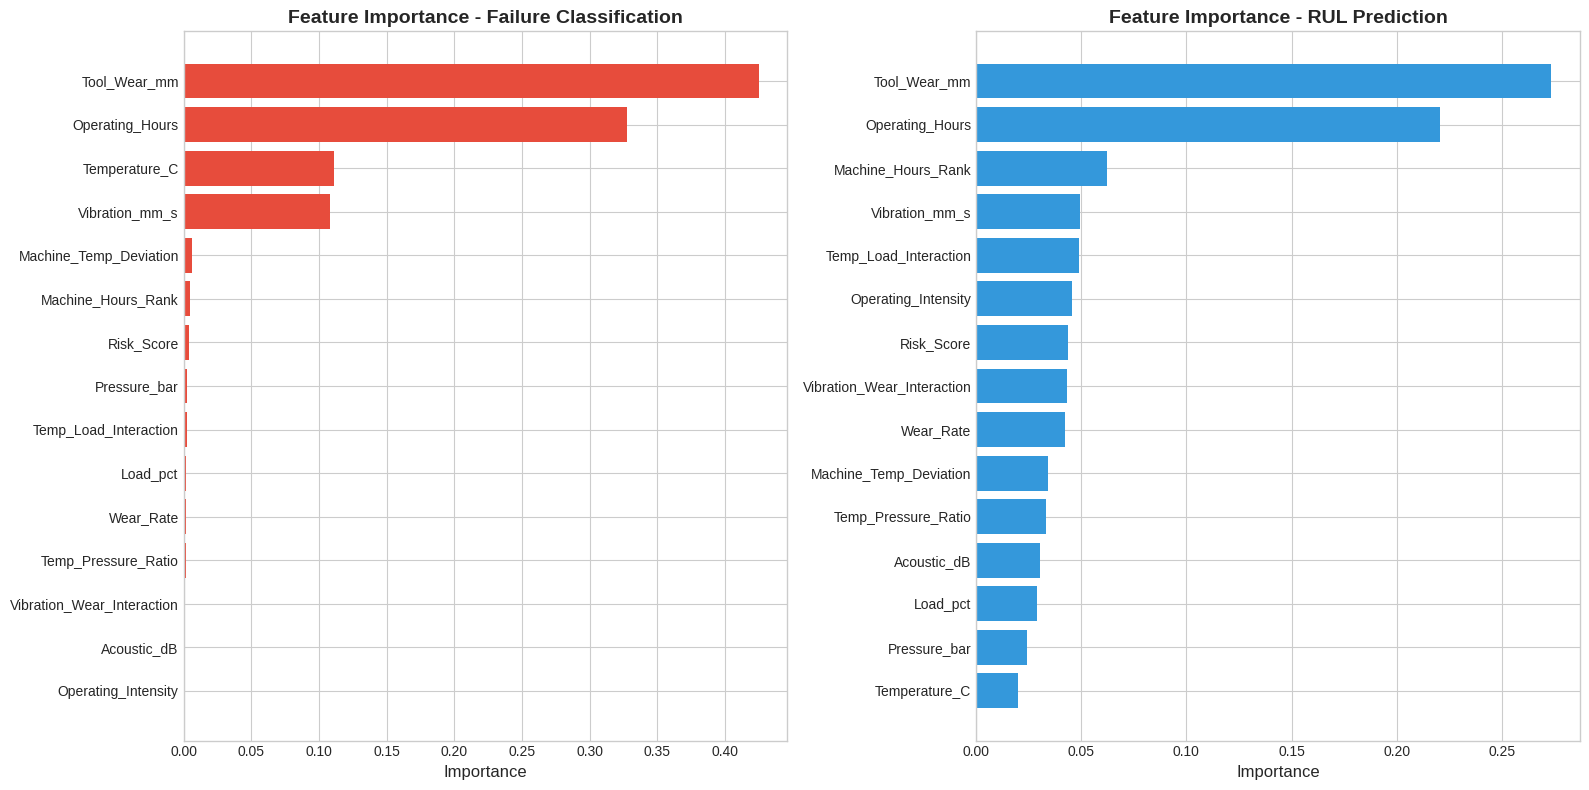


📌 Key Insights from Feature Importance:

  🔧 Most Important Features for Failure Detection:
     Tool_Wear_mm: 0.4249
     Operating_Hours: 0.3278
     Temperature_C: 0.1111
     Vibration_mm_s: 0.1084
     Machine_Temp_Deviation: 0.0064

  ⏱️ Most Important Features for RUL Prediction:
     Tool_Wear_mm: 0.2735
     Operating_Hours: 0.2207
     Machine_Hours_Rank: 0.0624
     Vibration_mm_s: 0.0494
     Temp_Load_Interaction: 0.0488


In [16]:
# FEATURE IMPORTANCE ANALYSIS

print("FEATURE IMPORTANCE ANALYSIS")

clf_importance = pd.DataFrame({
    'Feature': feature_columns,
    'Importance': best_clf_tuned.feature_importances_
}).sort_values('Importance', ascending=False)

print("\n📌 Top 15 Features for Failure Prediction:")
print(clf_importance.head(15).to_string(index=False))

reg_importance = pd.DataFrame({
    'Feature': feature_columns,
    'Importance': best_reg_tuned.feature_importances_
}).sort_values('Importance', ascending=False)

print("\n📌 Top 15 Features for RUL Prediction:")
print(reg_importance.head(15).to_string(index=False))

fig, axes = plt.subplots(1, 2, figsize=(16, 8))

top_clf = clf_importance.head(15)
axes[0].barh(range(len(top_clf)), top_clf['Importance'], color='#e74c3c')
axes[0].set_yticks(range(len(top_clf)))
axes[0].set_yticklabels(top_clf['Feature'])
axes[0].invert_yaxis()
axes[0].set_xlabel('Importance', fontsize=12)
axes[0].set_title('Feature Importance - Failure Classification', fontsize=14, fontweight='bold')


top_reg = reg_importance.head(15)
axes[1].barh(range(len(top_reg)), top_reg['Importance'], color='#3498db')
axes[1].set_yticks(range(len(top_reg)))
axes[1].set_yticklabels(top_reg['Feature'])
axes[1].invert_yaxis()
axes[1].set_xlabel('Importance', fontsize=12)
axes[1].set_title('Feature Importance - RUL Prediction', fontsize=14, fontweight='bold')

plt.tight_layout()
plt.savefig('feature_importance.png', dpi=300, bbox_inches='tight')
plt.show()

print("\n📌 Key Insights from Feature Importance:")
print(f"\n  🔧 Most Important Features for Failure Detection:")
for i, row in clf_importance.head(5).iterrows():
    print(f"     {row['Feature']}: {row['Importance']:.4f}")

print(f"\n  ⏱️ Most Important Features for RUL Prediction:")
for i, row in reg_importance.head(5).iterrows():
    print(f"     {row['Feature']}: {row['Importance']:.4f}")

In [17]:
# MODEL SAVING & DEPLOYMENT PREPARATION

print("MODEL SAVING & DEPLOYMENT PREPARATION")

print("\n📌 Saving Models...")
joblib.dump(best_clf_tuned, 'failure_classifier.pkl')
print("  ✓ Classification model saved: failure_classifier.pkl")
joblib.dump(best_reg_tuned, 'rul_predictor.pkl')
print("  ✓ Regression model saved: rul_predictor.pkl")
joblib.dump(scaler, 'feature_scaler.pkl')
print("  ✓ Feature scaler saved: feature_scaler.pkl")

joblib.dump(feature_columns, 'feature_columns.pkl')
print("  ✓ Feature list saved: feature_columns.pkl")

def predict_maintenance(input_data, scaler, clf_model, reg_model, feature_columns):

    if isinstance(input_data, dict):
        input_df = pd.DataFrame([input_data])
    else:
        input_df = input_data.copy()

    input_df = engineer_features(input_df)
    X_new = input_df[feature_columns]
    X_new_scaled = scaler.transform(X_new)

    failure_prob = clf_model.predict_proba(X_new_scaled)[:, 1][0]
    failure_pred = clf_model.predict(X_new_scaled)[0]
    rul_pred = reg_model.predict(X_new_scaled)[0]

    if failure_prob >= 0.7:
        risk_level = "CRITICAL"
    elif failure_prob >= 0.5:
        risk_level = "HIGH"
    elif failure_prob >= 0.3:
        risk_level = "MEDIUM"
    else:
        risk_level = "LOW"

    return {
        'failure_probability': round(failure_prob, 4),
        'failure_prediction': 'Yes' if failure_pred == 1 else 'No',
        'risk_level': risk_level,
        'predicted_rul_hours': round(rul_pred, 1),
        'predicted_rul_days': round(rul_pred / 24, 1),
        'recommended_action': get_recommendation(risk_level, rul_pred)
    }

def get_recommendation(risk_level, rul_hours):
    if risk_level == "CRITICAL":
        return "IMMEDIATE MAINTENANCE REQUIRED - Schedule within 24 hours"
    elif risk_level == "HIGH":
        return f"Schedule maintenance within {min(rul_hours/24, 7):.0f} days"
    elif risk_level == "MEDIUM":
        return f"Plan maintenance within {min(rul_hours/24, 14):.0f} days"
    else:
        return f"Normal operation - Next inspection in {min(rul_hours/24, 30):.0f} days"

print("\n📌 Testing Prediction Function...")

sample_input = {
    'Machine_ID': 1,
    'Temperature_C': 75.5,
    'Vibration_mm_s': 2.8,
    'Pressure_bar': 5.2,
    'Acoustic_dB': 65.0,
    'Tool_Wear_mm': 1.5,
    'Operating_Hours': 3500,
    'Load_pct': 85.0
}

print("\n📌 Sample Prediction:")
print(f"  Input: {sample_input}")

print("\n✅ All models and artifacts saved successfully!")
print("\n📁 Deployment Artifacts:")
print("  • failure_classifier.pkl - Classification model")
print("  • rul_predictor.pkl - Regression model")
print("  • feature_scaler.pkl - Feature scaler")
print("  • feature_columns.pkl - Feature list")

MODEL SAVING & DEPLOYMENT PREPARATION

📌 Saving Models...
  ✓ Classification model saved: failure_classifier.pkl
  ✓ Regression model saved: rul_predictor.pkl
  ✓ Feature scaler saved: feature_scaler.pkl
  ✓ Feature list saved: feature_columns.pkl

📌 Testing Prediction Function...

📌 Sample Prediction:
  Input: {'Machine_ID': 1, 'Temperature_C': 75.5, 'Vibration_mm_s': 2.8, 'Pressure_bar': 5.2, 'Acoustic_dB': 65.0, 'Tool_Wear_mm': 1.5, 'Operating_Hours': 3500, 'Load_pct': 85.0}

✅ All models and artifacts saved successfully!

📁 Deployment Artifacts:
  • failure_classifier.pkl - Classification model
  • rul_predictor.pkl - Regression model
  • feature_scaler.pkl - Feature scaler
  • feature_columns.pkl - Feature list
